# 复现并扩展 Steve Loughran 价值选股策略在 A 股市场的回测研究

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import statsmodels.formula.api as smf
import plotnine as p9
from regtabletotext import prettify_result

import warnings
warnings.filterwarnings("ignore")  # 忽略所有 warning


def sw_report_available_date(date_series):
    """Approximate A-share report availability dates used for financial factors."""
    dates = pd.to_datetime(date_series)
    month = dates.dt.month
    return pd.Series(
        np.select(
            [
                month.eq(3),
                month.eq(6),
                month.eq(9),
                month.eq(12),
            ],
            [
                dates + pd.offsets.MonthEnd(1),
                dates + pd.offsets.MonthEnd(2),
                dates + pd.offsets.MonthEnd(1),
                dates + pd.offsets.MonthEnd(4),
            ],
            default=dates + pd.offsets.MonthEnd(4),
        ),
        index=dates.index,
    )


START_DATE = "2003-01-01"
END_DATE = "2015-05-31"


## 数据清洗

### pb

In [2]:
pb = pd.read_csv("D:/stata/多因子检验/因子/市净率.csv")
pb = (
    pb
    .rename(columns={'Stkcd': 'stkcd',
                    'Accper': 'date',
                    'F100401A': 'pb'})
    .drop(columns=['ShortName', 'Source'])
    .assign(date=lambda x: sw_report_available_date(x['date']))
    .drop_duplicates(subset=['stkcd', 'date'], keep='last')
    .set_index('date')
    .groupby('stkcd')['pb']
    .resample('ME')
    .ffill()
    .reset_index()
    .query("date >= @START_DATE and date <= @END_DATE")
)
pb.head()

,stkcd,date,pb
21,1,2003-01-31,6.602438
22,1,2003-02-28,6.602438
23,1,2003-03-31,6.602438
24,1,2003-04-30,5.850519
25,1,2003-05-31,5.850519


In [3]:
pb_month = (
    pb
    .assign(pb_market=lambda x: x.groupby('date')['pb'].transform('mean'))
    .query('pb < pb_market')
    .get(['date', 'stkcd', 'pb'])
)
pb_month.head()

,date,stkcd,pb
30,2003-10-31,1,4.481086
31,2003-11-30,1,4.481086
32,2003-12-31,1,4.481086
33,2004-01-31,1,4.481086
34,2004-02-29,1,4.481086


### pe

In [4]:
net_profit = pd.read_csv("D:/stata/多因子检验/因子/净利润.csv")
net_profit = (
    net_profit
    .query("Typrep == 'A'")
    .rename(columns={'Stkcd': 'stkcd',
                     'Accper': 'date',
                     'B002000000': 'net_profit'})
    .drop(columns=['ShortName', 'Typrep'])
    .assign(date=lambda x: pd.to_datetime(x['date']))
    .dropna(subset=['net_profit'])
    .query("date.dt.month == 12 and net_profit > 0")
    .sort_values(by=['stkcd', 'date'])
    .groupby('stkcd', group_keys=False)
    .apply(lambda x: x.assign(
        stkcd=x.name,
        profit_5y_avg=lambda x: x['net_profit'].rolling(5).mean()
    ))
    .reset_index(drop=True)
)

net_profit.head()

,date,net_profit,stkcd,profit_5y_avg
0,1993-12-31,2.733111e+08,1,NaN
1,1994-12-31,3.563280e+08,1,NaN
2,1995-12-31,4.350597e+08,1,NaN
3,1996-12-31,7.873006e+08,1,NaN
4,1997-12-31,8.203918e+08,1,5.344783e+08


In [5]:
net_profit_month = (
    net_profit
    .assign(date=lambda x: pd.to_datetime(x['date']) + pd.offsets.MonthEnd(4))
    .set_index('date')
    .groupby('stkcd')['profit_5y_avg']
    .resample('ME')
    .ffill()
    .reset_index()
    .dropna(subset=['profit_5y_avg'])
    .query("date >= @START_DATE and date <= @END_DATE")
)
net_profit_month.head()

,stkcd,date,profit_5y_avg
105,1,2003-01-31,6.097488e+08
106,1,2003-02-28,6.097488e+08
107,1,2003-03-31,6.097488e+08
108,1,2003-04-30,5.321155e+08
109,1,2003-05-31,5.321155e+08


In [6]:
market_value = pd.read_csv("D:/stata/多因子检验/因子/总市值.csv")
market_value = (
    market_value
    .rename(columns={'Stkcd': 'stkcd',
                     'Trdmnt': 'date',
                     'Msmvttl': 'market_value'})
    .assign(date=lambda x: pd.to_datetime(x['date'])+pd.offsets.MonthEnd(0),
            market_value=lambda x: x['market_value'] * 10000)  # 将市值单位从万元转换为元

)
market_value.head()

,stkcd,date,market_value
0,1,1991-04-30,2.118487e+10
1,1,1991-05-31,1.859497e+10
2,1,1991-06-30,1.648521e+10
3,1,1991-07-31,1.432695e+10
4,1,1991-08-31,1.346275e+10


In [7]:
pe = (
    net_profit_month
    .merge(market_value, on=['stkcd', 'date'], how='inner')
    .assign(pe=lambda x: x['market_value'] / x['profit_5y_avg'],
            pe_mean=lambda x: x.groupby('date')['pe'].transform('mean'))
    .query("pe < pe_mean")
    .get(['date', 'stkcd', 'pe'])
)
pe.head()

,date,stkcd,pe
0,2003-01-31,1,371.134969
1,2003-02-28,1,359.646698
2,2003-03-31,1,376.240867
3,2003-04-30,1,454.536105
4,2003-05-31,1,458.924225


### 每股流动资产

In [8]:
current_assets_raw = pd.read_csv("D:/stata/多因子检验/因子/流动资产合计.csv", encoding='gbk')
current_assets_raw = (
    current_assets_raw
    .query("Typrep == 'A'")
    .rename(columns={
        'Stkcd': 'stkcd',
        'Accper': 'date',
        'A001100000': 'current_assets'
    })
    .assign(date=lambda x: sw_report_available_date(x['date']))
    .drop(columns=['ShortName', 'Typrep'])
    .drop_duplicates(subset=['stkcd', 'date'], keep='last')
    .dropna(subset=['current_assets'])
    .set_index('date')
    .groupby('stkcd')['current_assets']
    .resample('ME')
    .ffill()
    .reset_index()
)
current_assets_raw.head()

,stkcd,date,current_assets
0,2,2001-04-30,4.992221e+09
1,2,2001-05-31,4.992221e+09
2,2,2001-06-30,4.992221e+09
3,2,2001-07-31,4.992221e+09
4,2,2001-08-31,5.520204e+09


In [9]:
total_shares = pd.read_csv("D:/stata/多因子检验/因子/总股本.csv")
total_shares = (
    total_shares
    .rename(columns={
        'Symbol': 'stkcd',
        'EndDate': 'date',
        'TotalShares': 'total_shares'
    })
    .assign(date=lambda x: sw_report_available_date(x['date']))
    .dropna(subset=['total_shares'])
    .drop_duplicates(subset=['stkcd', 'date'], keep='last')
    .set_index('date')
    .groupby('stkcd')['total_shares']
    .resample('ME')
    .ffill()
    .reset_index()
)

stock_price_for_current_assets = pd.read_csv("D:/stata/多因子检验/因子/月个股收盘价.csv")
stock_price_for_current_assets = (
    stock_price_for_current_assets
    .rename(columns={'Stkcd': 'stkcd',
                     'Trdmnt': 'date',
                     'Mclsprc': 'price'})
    .assign(date=lambda x: pd.to_datetime(x['date']) + pd.offsets.MonthEnd(0))
)

current_assets_to_price = (
    current_assets_raw
    .merge(total_shares, on=['stkcd', 'date'], how='inner')
    .merge(stock_price_for_current_assets, on=['stkcd', 'date'], how='inner')
    .assign(current_assets_to_price=lambda x: (x['current_assets'] / x['total_shares']) / x['price'])
    .query('current_assets_to_price >= 0.3 and date >= @START_DATE and date <= @END_DATE')
    .get(['date', 'stkcd', 'current_assets_to_price'])
)
current_assets_to_price.head()

,date,stkcd,current_assets_to_price
0,2003-04-30,2,0.969396
1,2003-05-31,2,1.745728
2,2003-06-30,2,2.138667
3,2003-07-31,2,1.954009
4,2003-08-31,2,1.009449


### 股息收益率

In [10]:
dps = pd.read_csv("D:/stata/多因子检验/因子/每股现金股利.csv")
dps = (
    dps
    .rename(columns={'Stkcd': 'stkcd',
                    'Accper': 'date',
                    'F110101B': 'dps'})
    .query("Typrep == 'A'")
    .assign(date=lambda x: pd.to_datetime(x['date']),
            dps=lambda x: x['dps'].fillna(0))
    .drop(columns=['ShortName', 'Typrep', 'Source'])
    .sort_values(by=['stkcd', 'date'])
    .query('date.dt.month == 12')
)
dps.head()

,stkcd,date,dps
0,1,1990-12-31,0.3
1,1,1991-12-31,0.2
2,1,1992-12-31,0.3
3,1,1993-12-31,0.5
4,1,1994-12-31,0.3


In [11]:
dps_month = (
    dps
    .assign(date=lambda x: pd.to_datetime(x['date']) + pd.offsets.MonthEnd(4))
    .set_index('date')
    .groupby('stkcd')['dps']
    .resample('ME')
    .ffill()
    .reset_index()
)
dps_month.head()

,stkcd,date,dps
0,1,1991-04-30,0.3
1,1,1991-05-31,0.3
2,1,1991-06-30,0.3
3,1,1991-07-31,0.3
4,1,1991-08-31,0.3


In [12]:
stock_price = pd.read_csv("D:/stata/多因子检验/因子/月个股收盘价.csv")
stock_price = (
    stock_price
    .rename(columns={'Stkcd': 'stkcd',
                     'Trdmnt': 'date',
                     'Mclsprc': 'price'})
    .assign(date=lambda x: pd.to_datetime(x['date'])+pd.offsets.MonthEnd(0))
)
stock_price.head()

,stkcd,date,price
0,1,2000-12-31,14.52
1,1,2001-01-31,14.98
2,1,2001-02-28,14.09
3,1,2001-03-31,16.22
4,1,2001-04-30,15.53


In [13]:
dividend_yield = (
    dps_month
    .merge(stock_price, on=['stkcd', 'date'], how='left')
    .assign(dividend_yield=lambda x: x['dps'] / x['price'],
            dividend_yield_mean=lambda x: x.groupby('date')['dividend_yield'].transform('mean'))
    .query("dividend_yield >= dividend_yield_mean")
    .get(['date', 'stkcd', 'dividend_yield'])
    .query("date >= '2003-01-01' and date <= '2015-05-31'")
)
dividend_yield.head()

,date,stkcd,dividend_yield
141,2003-01-31,1,0.012898
142,2003-02-28,1,0.013310
143,2003-03-31,1,0.012723
144,2003-04-30,1,0.012068
145,2003-05-31,1,0.011952


### 股价现金流

In [14]:
operating_cash_flow = pd.read_csv("D:/stata/多因子检验/因子/经营活动产生的现金流量.csv")
operating_cash_flow = (
    operating_cash_flow
    .rename(columns={'Stkcd': 'stkcd',
                     'Accper': 'date',
                     'C001000000': 'operating_cash_flow'})
    .assign(date=lambda x: sw_report_available_date(x['date']))
    .query("Typrep == 'A'")
    .dropna(subset=['operating_cash_flow'])
    .query("operating_cash_flow > 0")
    .drop(columns=['ShortName', 'Typrep'])
    .drop_duplicates(subset=['stkcd', 'date'], keep='last')
    .set_index('date')
    .groupby('stkcd')['operating_cash_flow']
    .resample('ME')
    .ffill()
    .reset_index()
    .query("date >= @START_DATE and date <= @END_DATE")
)
operating_cash_flow.head()

,stkcd,date,operating_cash_flow
53,1,2003-01-31,1.464214e+10
54,1,2003-02-28,1.464214e+10
55,1,2003-03-31,1.464214e+10
56,1,2003-04-30,8.544036e+09
57,1,2003-05-31,8.544036e+09


In [15]:
pcf = (
    operating_cash_flow
    .merge(market_value, on=['stkcd', 'date'], how='inner')
    .assign(pcf=lambda x: x['market_value'] / x['operating_cash_flow'],
            pcf_mean=lambda x: x.groupby('date')['pcf'].transform('mean'))
    .query("pcf < pcf_mean")
    .get(['date', 'stkcd', 'pcf'])
)
pcf.head()

,date,stkcd,pcf
0,2003-01-31,1,15.455334
1,2003-02-28,1,14.976923
2,2003-03-31,1,15.667961
3,2003-04-30,1,28.308130
4,2003-05-31,1,28.581419


### 长期借款

In [16]:
debt_to_assets = pd.read_csv("D:/stata/多因子检验/因子/长期借款_总资本.csv")
debt_to_assets = (
    debt_to_assets
    .query("Typrep == 'A'")
    .rename(columns={
        'Stkcd': 'stkcd',
        'Accper': 'date',
        'A002201000': 'long_term_debt',
        'A003000000': 'total_capital'
    })
    .dropna(subset=['long_term_debt', 'total_capital'])
    .drop(columns=['ShortName', 'Typrep'])
    .assign(
        date=lambda x: sw_report_available_date(x['date']),
        debt_to_assets=lambda x: x['long_term_debt'] / x['total_capital']
    )
    .drop_duplicates(subset=['stkcd', 'date'], keep='last')
    .sort_values(['stkcd', 'date'])
    .set_index('date')
    .groupby('stkcd')['debt_to_assets']
    .resample('ME')
    .ffill()
    .reset_index()
    .query("date >= @START_DATE and date <= @END_DATE")
    .query("debt_to_assets < 0.5")
)
debt_to_assets.head()

,stkcd,date,debt_to_assets
45,1,2003-01-31,0.035375
46,1,2003-02-28,0.035375
47,1,2003-03-31,0.035375
48,1,2003-04-30,0.035375
49,1,2003-05-31,0.035375


### 流动比率

In [17]:
current_ratio = pd.read_csv("D:/stata/多因子检验/因子/流动比率.csv")
current_ratio = (
    current_ratio
    .rename(columns={'Stkcd': 'stkcd',
                     'Accper': 'date',
                     'A001100000': 'current_assets',
                     'A002100000': 'current_liabilities'})
    .assign(date=lambda x: sw_report_available_date(x['date']))
    .query("Typrep == 'A'")
    .dropna(subset=['current_assets', 'current_liabilities'])
    .drop(columns=['ShortName', 'Typrep'])
    .drop_duplicates(subset=['stkcd', 'date'], keep='last')
    .set_index('date')
    .groupby('stkcd')[['current_assets', 'current_liabilities']]
    .resample('ME')
    .ffill()
    .reset_index()
    .query("date >= @START_DATE and date <= @END_DATE")
    .assign(current_ratio=lambda x: x['current_assets'] / x['current_liabilities'],
            current_ratio_mean=lambda x: x.groupby('date')['current_ratio'].transform('mean'))
    .query("current_ratio > current_ratio_mean")
    .get(['date', 'stkcd', 'current_ratio'])
)
current_ratio.head()

,date,stkcd,current_ratio
436,2003-01-31,2,2.444473
437,2003-02-28,2,2.444473
438,2003-03-31,2,2.444473
443,2003-08-31,2,2.172527
444,2003-09-30,2,2.172527


## 股票池

In [18]:
final = (
    pb_month
    .merge(pe, on=['stkcd', 'date'], how='inner')
    .merge(current_assets_to_price, on=['stkcd', 'date'], how='inner')
    .merge(dividend_yield, on=['stkcd', 'date'], how='inner')
    .merge(pcf, on=['stkcd', 'date'], how='inner')
    .merge(debt_to_assets, on=['stkcd', 'date'], how='inner')
    .merge(current_ratio, on=['stkcd', 'date'], how='inner')
)
stock_num = (
    final
    .groupby('date')['stkcd']
    .nunique()
    .reset_index(name='stock_num')
)
stock_num.describe()

,date,stock_num
count,122,122.000000
mean,2010-01-16 09:38:21.639344,24.344262
min,2003-08-31 00:00:00,4.000000
25%,2007-01-07 18:00:00,9.000000
50%,2010-05-15 12:00:00,22.000000
75%,2012-11-22 12:00:00,38.000000
max,2015-05-31 00:00:00,53.000000
std,NaN,14.851758


说明：当前本地数据只包含月个股收盘价，因此组合收益按月频计算；若补充个股日收益或日复权价，可进一步改成申万报告中的日频净值和 2938 个交易日口径。

## 日频净值回测（按申万报告分块）

In [19]:
daily_price_files = [
    f"D:\\stata\\多因子检验\\因子\\TRD_Dalyr0{i}.csv"
    for i in range(1, 8)
]

daily_price = pd.concat(
    [
        pd.read_csv(file, usecols=['Stkcd', 'Trddt', 'Clsprc'])
        for file in daily_price_files
    ],
    ignore_index=True
)

daily_price = (
    daily_price
    .rename(columns={'Stkcd': 'stkcd', 'Trddt': 'date', 'Clsprc': 'close'})
    .assign(date=lambda x: pd.to_datetime(x['date']))
    .dropna(subset=['close'])
    .sort_values(by=['stkcd', 'date'])
)

daily_price.head()

,stkcd,date,close
0,1,2003-01-02,10.03
1,1,2003-01-03,10.02
2,1,2003-01-06,10.06
3,1,2003-01-07,10.04
4,1,2003-01-08,10.53


In [20]:
daily_stock_return = (
    daily_price
    .assign(stock_return=lambda x: x.groupby('stkcd')['close'].pct_change())
    .dropna(subset=['stock_return'])
    .get(['stkcd', 'date', 'stock_return'])
)
daily_stock_return.head()

,stkcd,date,stock_return
1,1,2003-01-03,-0.000997
2,1,2003-01-06,0.003992
3,1,2003-01-07,-0.001988
4,1,2003-01-08,0.048805
5,1,2003-01-09,0.015195


In [21]:
trading_days = (
    pd.Index(
        daily_stock_return
        .query("date >= @START_DATE and date <= @END_DATE")['date']
        .drop_duplicates()
        .sort_values()
    )
)

In [22]:
signal_holdings = (
    final
    .get(['date', 'stkcd'])
    .drop_duplicates()
    .sort_values(by=['date', 'stkcd'])
    .reset_index(drop=True)
)
signal_holdings.head()

,date,stkcd
0,2003-08-31,2
1,2003-08-31,62
2,2003-08-31,400
3,2003-08-31,530
4,2003-08-31,541


In [23]:
signal_dates = (
    pd.Index(
        signal_holdings['date']
        .drop_duplicates()
        .sort_values()
    )
)

In [24]:
DAILY_TRANSACTION_COST = 0.0013


In [25]:
daily_holdings_parts = []
daily_turnover_rows = []
last_weights = {}

for idx, signal_date in enumerate(signal_dates):
   stocks = set(
    signal_holdings
    .query("date == @signal_date")['stkcd']
   )
   if not stocks:
       continue

   next_signal_date = signal_dates[idx + 1] if idx + 1 < len(signal_dates) else pd.to_datetime(END_DATE)
   period_days = trading_days[(trading_days > signal_date) & (trading_days <= next_signal_date)]
   if len(period_days) == 0:
       continue

   weight = 1 / len(stocks)
   new_weights = {
    stkcd: weight for stkcd in stocks
   }

   all_stocks = (
    set(last_weights)
    |
    set(new_weights)
   )
   turnover = sum(
    abs(new_weights.get(stkcd, 0) - last_weights.get(stkcd, 0))
    for stkcd in all_stocks
   )

   daily_turnover_rows.append(
    {
        'date': period_days[0],
        'turnover': turnover,
        'cost': turnover * DAILY_TRANSACTION_COST,
        'holding_count': len(stocks)
    }
   )

   daily_holdings_parts.append(
    pd.MultiIndex.from_product(
        [period_days, sorted(stocks)], names=['date', 'stkcd']
    )
    .to_frame(index=False)
    .assign(weight=weight, signal_date=signal_date)
   )
   last_weights = new_weights

daily_holdings = pd.concat(daily_holdings_parts, ignore_index=True)
daily_turnover = (
        pd.DataFrame(daily_turnover_rows)
        .groupby('date', as_index=False)[['turnover', 'cost', 'holding_count']]
        .sum()
    )


In [26]:
daily_holdings.head()

,date,stkcd,weight,signal_date
0,2003-09-01,2,0.035714,2003-08-31
1,2003-09-01,62,0.035714,2003-08-31
2,2003-09-01,400,0.035714,2003-08-31
3,2003-09-01,530,0.035714,2003-08-31
4,2003-09-01,541,0.035714,2003-08-31


In [27]:
daily_turnover.head()

,date,turnover,cost,holding_count
0,2003-09-01,1.000000,0.001300,28
1,2003-10-08,0.266667,0.000347,30
2,2003-11-03,0.571429,0.000743,35
3,2003-12-01,0.166667,0.000217,36
4,2004-01-02,0.333333,0.000433,32


In [28]:
portfolio_daily_gross = (
    daily_holdings
    .merge(daily_stock_return, on=['date', 'stkcd'], how='inner')
    .drop_duplicates(subset=['date', 'stkcd'], keep='first')
    .groupby('date')
    .apply(lambda x: (x['weight'] * x['stock_return']).sum())
    .reset_index(name='portfolio_daily_gross')
)
portfolio_daily_gross.head()

,date,portfolio_daily_gross
0,2003-09-01,0.018866
1,2003-09-02,0.000187
2,2003-09-03,0.003512
3,2003-09-04,-0.002476
4,2003-09-05,-0.010615


In [29]:
portfolio_daily = (
    portfolio_daily_gross
    .merge(daily_turnover, on='date', how='left', validate='one_to_one')
    .assign(
        turnover=lambda x: x['turnover'].fillna(0),
        cost=lambda x: x['cost'].fillna(0),
        portfolio_return=lambda x: x['portfolio_daily_gross'] - x['cost'],
        portfolio_nav=lambda x: (1 + x['portfolio_return']).cumprod()
    )
)
portfolio_daily.head()

,date,portfolio_daily_gross,turnover,cost,holding_count,portfolio_return,portfolio_nav
0,2003-09-01,0.018866,1.0,0.0013,28.0,0.017566,1.017566
1,2003-09-02,0.000187,0.0,0.0000,NaN,0.000187,1.017756
2,2003-09-03,0.003512,0.0,0.0000,NaN,0.003512,1.021331
3,2003-09-04,-0.002476,0.0,0.0000,NaN,-0.002476,1.018802
4,2003-09-05,-0.010615,0.0,0.0000,NaN,-0.010615,1.007988


In [30]:
benchmark_daily = pd.read_csv("D:/stata/多因子检验/上证指数合并后历史数据.csv")
benchmark_daily = (
    benchmark_daily
    .assign(
        date=lambda x: pd.to_datetime(x['date']),
        benchmark_return=lambda x: (
            x['return']
            .astype(str)
            .str.rstrip('%')
            .astype(float)/100
        )
    )
    .query("date >= @START_DATE and date <= @END_DATE")
    .get(['date', 'benchmark_return'])
)
benchmark_daily.head()

,date,benchmark_return
712,2003-01-02,-0.0273
713,2003-01-03,-0.0006
714,2003-01-06,0.0112
715,2003-01-07,-0.0020
716,2003-01-08,0.0300


In [31]:
daily_backtest = (
    portfolio_daily
    .merge(benchmark_daily, on='date', how='inner')
    .assign(
        benchmark_nav=lambda x: (1 + x['benchmark_return']).cumprod(),
        excess_return=lambda x: x['portfolio_return'] - x['benchmark_return'],
        excess_nav=lambda x: (1 + x['excess_return']).cumprod()
    )
    .drop(columns=['portfolio_daily_gross', 'turnover', 'cost'])
)
daily_backtest.head()

,date,holding_count,portfolio_return,portfolio_nav,benchmark_return,benchmark_nav,excess_return,excess_nav
0,2003-09-01,28.0,0.017566,1.017566,0.0196,1.019600,-0.002034,0.997966
1,2003-09-02,NaN,0.000187,1.017756,-0.0023,1.017255,0.002487,1.000447
2,2003-09-03,NaN,0.003512,1.021331,0.0009,1.018170,0.002612,1.003061
3,2003-09-04,NaN,-0.002476,1.018802,-0.0003,1.017865,-0.002176,1.000879
4,2003-09-05,NaN,-0.010615,1.007988,-0.0110,1.006668,0.000385,1.001265


### 核心指标计算

#### 核心指标可视化


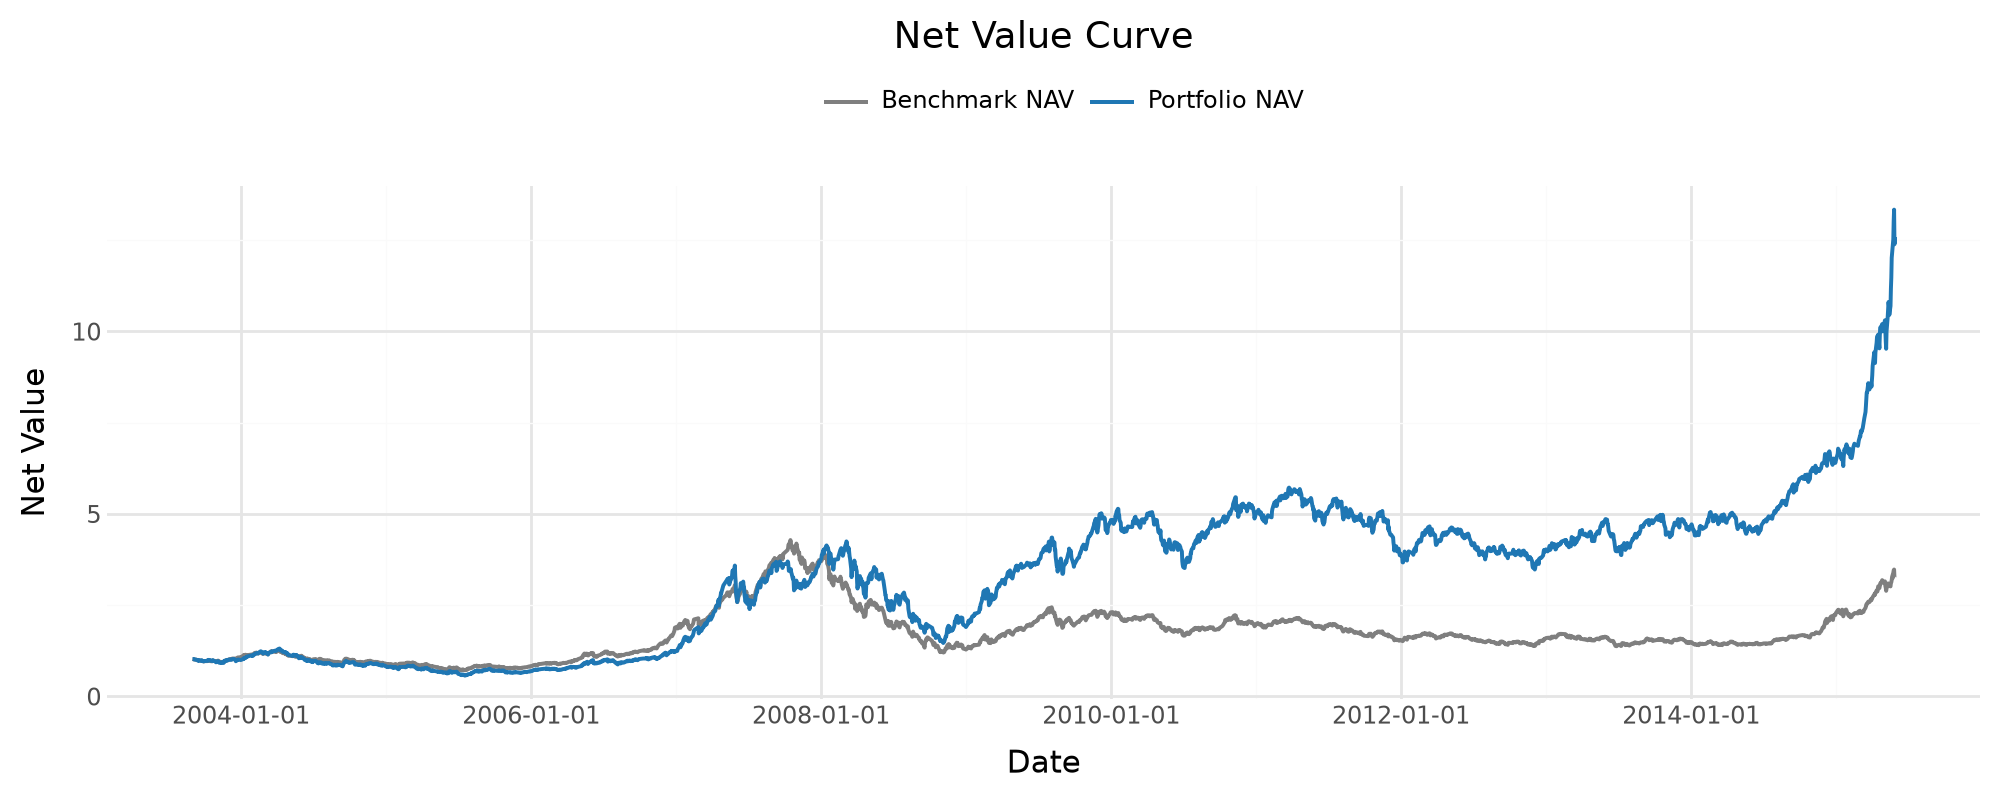

In [32]:
# Plotnine visualization for core metrics
nav_plot_data = (
    daily_backtest
    .get(['date', 'portfolio_nav', 'benchmark_nav'])
    .melt(id_vars='date', var_name='curve', value_name='nav')
    .assign(
        curve=lambda x: x['curve'].map({
            'portfolio_nav': 'Portfolio NAV',
            'benchmark_nav': 'Benchmark NAV'
        })
    )
)

nav_plot = (
    p9.ggplot(nav_plot_data, p9.aes(x='date', y='nav', color='curve'))
    + p9.geom_line(size=0.8)
    + p9.scale_color_manual(values={'Portfolio NAV': '#1f77b4', 'Benchmark NAV': '#7f7f7f'})
    + p9.labs(title='Net Value Curve', x='Date', y='Net Value', color='')
    + p9.theme_minimal()
    + p9.theme(figure_size=(10, 4), legend_position='top')
)

display(nav_plot)


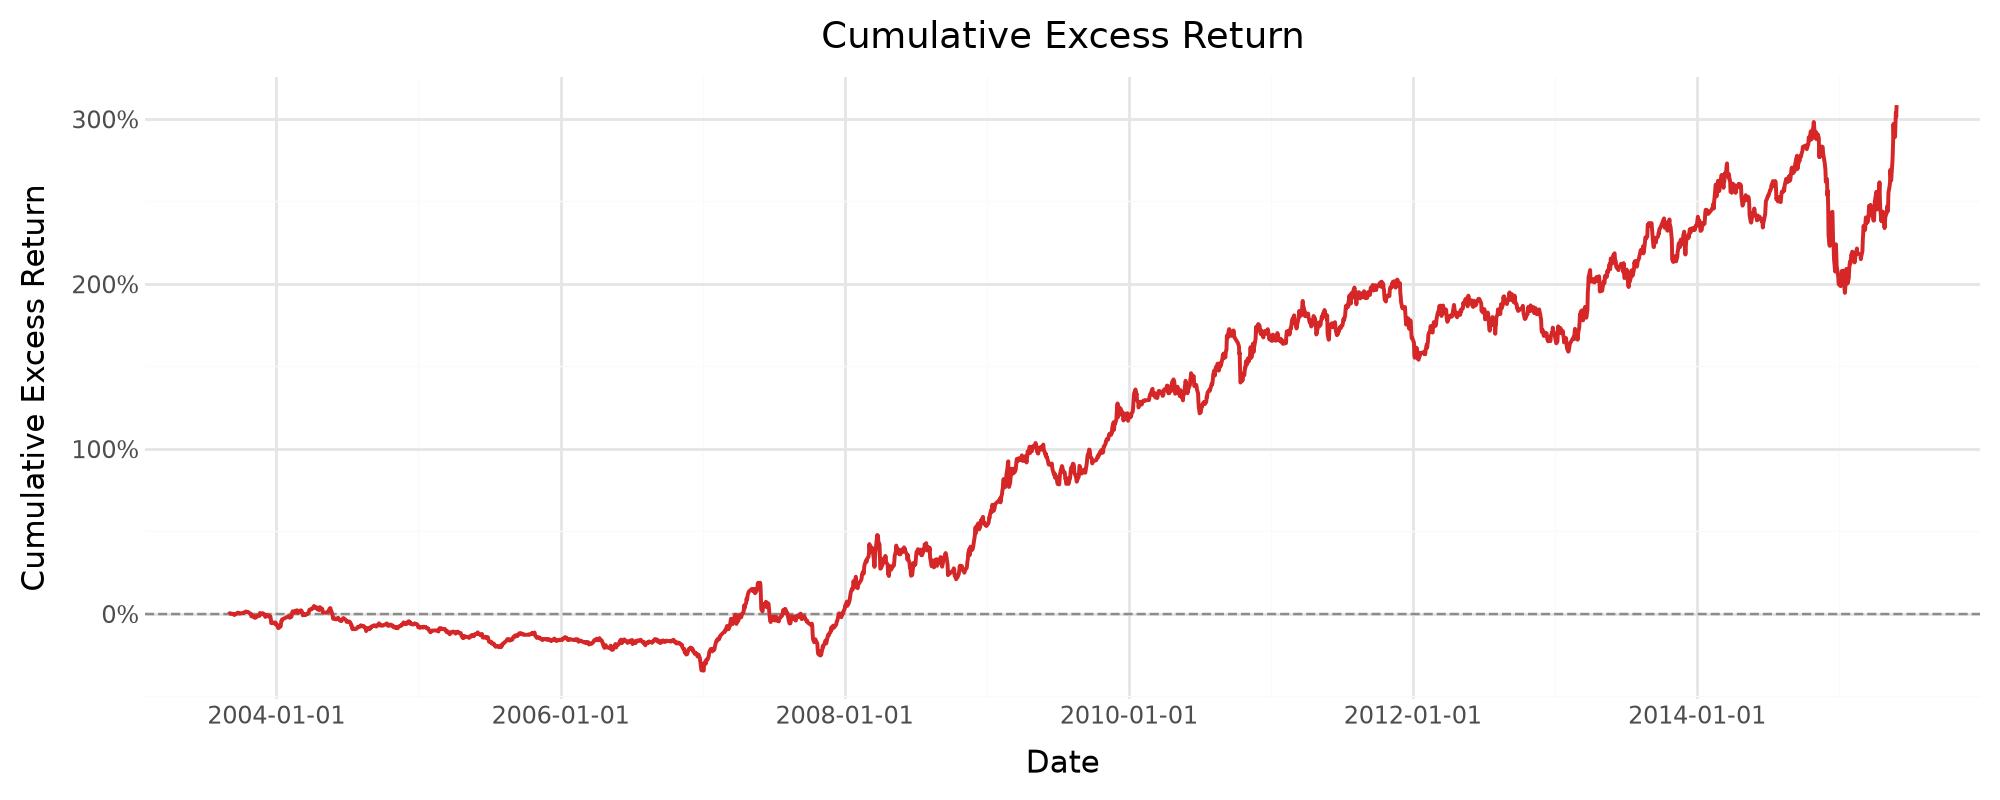

In [33]:
excess_plot_data = (
    daily_backtest
    .assign(cumulative_excess_return=lambda x: x['excess_nav'] - 1)
    .get(['date', 'cumulative_excess_return'])
)

excess_plot = (
    p9.ggplot(excess_plot_data, p9.aes(x='date', y='cumulative_excess_return'))
    + p9.geom_hline(yintercept=0, linetype='dashed', color='#8c8c8c', size=0.5)
    + p9.geom_line(color='#d62728', size=0.8)
    + p9.scale_y_continuous(labels=lambda values: [f'{value:.0%}' for value in values])
    + p9.labs(title='Cumulative Excess Return', x='Date', y='Cumulative Excess Return')
    + p9.theme_minimal()
    + p9.theme(figure_size=(10, 4))
)

display(excess_plot)


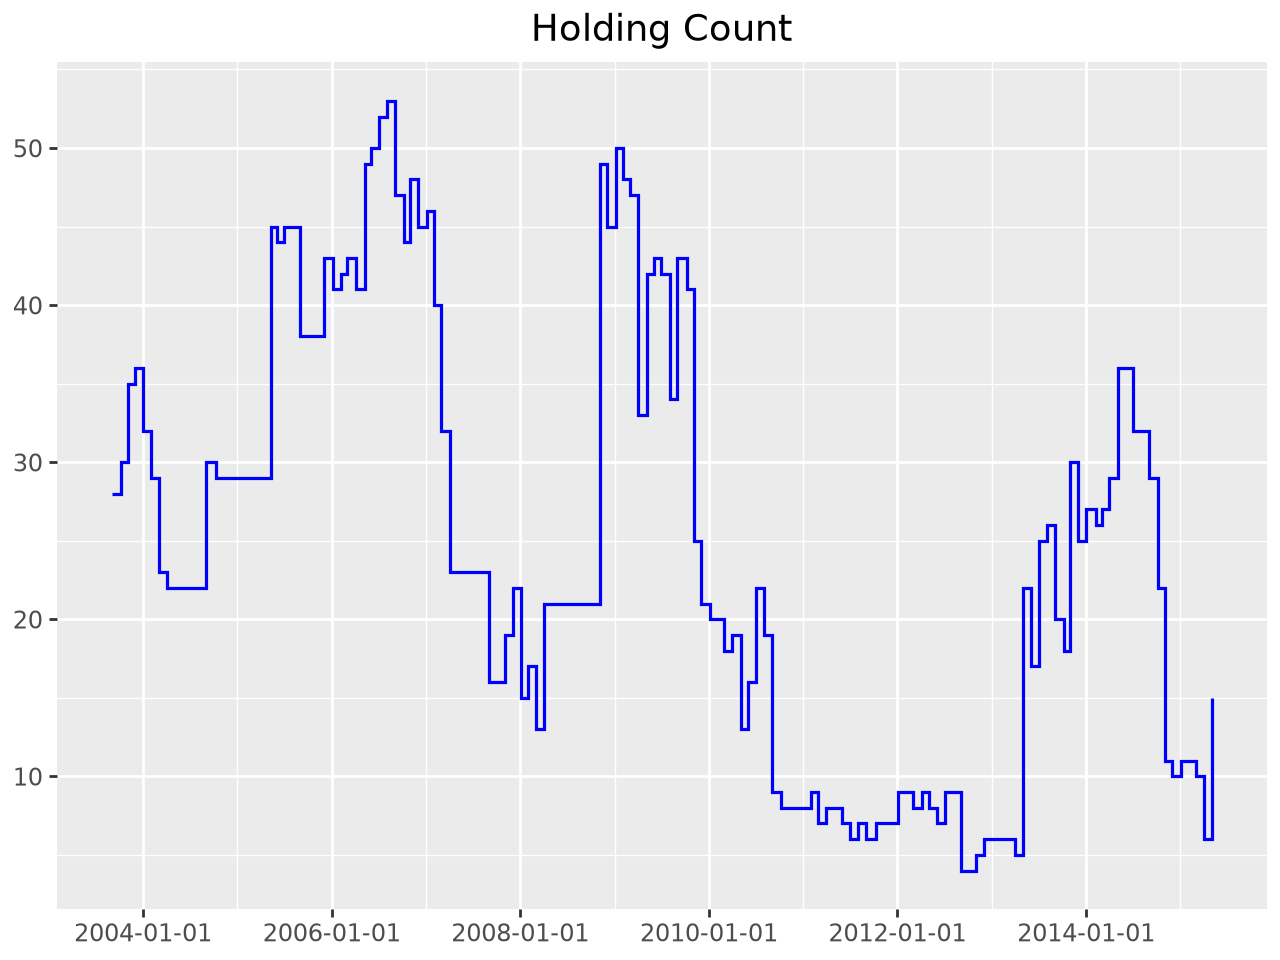

In [34]:
holding_count_data = (
    daily_turnover
    .get(['date', 'holding_count'])
    .sort_values('date')
)
holding_count = (
    p9.ggplot(holding_count_data, p9.aes(x='date', y='holding_count'))
    + p9.geom_step(color='blue', size=0.65)
    + p9.labs(
        title='Holding Count',
        x='',
        y=''
    )
    + p9.theme(legend_position='none')
)

display(holding_count)


#### 收益分析

In [35]:
def annulized_return(nav_series, reading_days=244):
    nav_series = nav_series.dropna()
    if len(nav_series) == 0:
        return np.nan
    return nav_series.iloc[-1] ** (reading_days / len(nav_series)) - 1

daily_return_summary = pd.DataFrame({
    'metric': [
        '交易日数',
        '组合累计收益',
        '组合年化收益',
        '上证指数累计收益',
        '上证指数年化收益',
        '年化超额收益'
    ],
    'value': [
        len(daily_backtest),
        daily_backtest['portfolio_nav'].iloc[-1] - 1,
        annulized_return(daily_backtest['portfolio_nav']),
        daily_backtest['benchmark_nav'].iloc[-1] - 1,
        annulized_return(daily_backtest['benchmark_nav']),
        annulized_return(daily_backtest['excess_nav'])
    ]
})

daily_return_summary

,metric,value
0,交易日数,2851.000000
1,组合累计收益,11.580733
2,组合年化收益,0.241988
3,上证指数累计收益,2.240465
4,上证指数年化收益,0.105859
5,年化超额收益,0.127989


#### 风险分析

In [36]:
def max_drawdown_info(nav, dates):
    drawdown = nav/ nav.cummax() - 1
    end_idx = drawdown.idxmin()
    start_idx = nav.iloc[:end_idx].idxmax()
    return {
        'max_drawdown': drawdown.loc[end_idx],
        'drawdown_start': dates.loc[start_idx],
        'drawdown_end': dates.loc[end_idx],
        'drawdown_days': (dates.loc[end_idx] - dates.loc[start_idx]).days
    }
        
def beta_to_benchmark(portfolio_return, benchmark_return):
    df = pd.DataFrame({
        'portfolio_return': portfolio_return,
        'benchmark_return': benchmark_return
    }).dropna()
    if len(df) < 2 or df['benchmark_return'].std() == 0:
        return np.nan
    model = smf.ols('portfolio_return ~ benchmark_return', data=df).fit()
    return model.params['benchmark_return']

drawdown_info = max_drawdown_info(daily_backtest['portfolio_nav'], daily_backtest['date'])
daily_risk_summary = pd.DataFrame({
    'metric':[
        '年化波动率',
        'Sharpe比率（无风险利率按0）',
        'Beta（相对上证指数）',
        '最大回撤',
        '最大回撤开始日',
        '最大回撤结束日',
        '最大回撤自然日数'
    ],
    'value':[
        daily_backtest['portfolio_return'].std() * np.sqrt(244),
        daily_backtest['portfolio_return'].mean() / daily_backtest['portfolio_return'].std() * np.sqrt(244),
        beta_to_benchmark(daily_backtest['portfolio_return'], daily_backtest['benchmark_return']),
        drawdown_info['max_drawdown'],
        drawdown_info['drawdown_start'],
        drawdown_info['drawdown_end'],
        drawdown_info['drawdown_days']
    ]
})
display(daily_risk_summary)

,metric,value
0,年化波动率,0.317771
1,Sharpe比率（无风险利率按0）,0.842434
2,Beta（相对上证指数）,1.060907
3,最大回撤,-0.656221
4,最大回撤开始日,2008-03-05 00:00:00
5,最大回撤结束日,2008-11-04 00:00:00
6,最大回撤自然日数,244


#### 盈亏统计

In [37]:
profit_days = daily_backtest.loc[daily_backtest['portfolio_return'] > 0, 'portfolio_return']
loss_days = daily_backtest.loc[daily_backtest['portfolio_return'] < 0, 'portfolio_return']

daily_profit_loss_summary = pd.DataFrame({
    'metric': [
        '盈利天数',
        '亏损天数',
        '胜率',
        '盈利日平均收益',
        '亏损日平均收益',
        '盈亏比'
    ],
    'value': [
        len(profit_days),
        len(loss_days),
        len(profit_days) / len(daily_backtest) if len(daily_backtest) > 0 else np.nan,
        profit_days.mean() if len(profit_days) > 0 else np.nan,
        loss_days.mean() if len(loss_days) > 0 else np.nan,
        profit_days.mean() / abs(loss_days.mean())
    ]
})
display(daily_profit_loss_summary)

,metric,value
0,盈利天数,1610.000000
1,亏损天数,1241.000000
2,胜率,0.564714
3,盈利日平均收益,0.014077
4,亏损日平均收益,-0.015742
5,盈亏比,0.894224


#### 持股个数

In [38]:
daily_holding_count_summary = pd.DataFrame({
    'metric': [
        '调仓期数',
        '平均每期持股数',
        '最少持股数',
        '最多持股数',
        '平均单边换手率',
        '平均交易成本'
    ],
    'value': [
        len(daily_turnover),
        daily_turnover['holding_count'].mean(),
        daily_turnover['holding_count'].min(),
        daily_turnover['holding_count'].max(),
        daily_turnover['turnover'].mean(),
        daily_turnover['cost'].mean()
    ]
})

display(daily_holding_count_summary)

,metric,value
0,调仓期数,121.000000
1,平均每期持股数,24.446281
2,最少持股数,4.000000
3,最多持股数,53.000000
4,平均单边换手率,0.467113
5,平均交易成本,0.000607


#### 行业分布

由于可获得的申万行业分类数据为 2014 修订版，本文不对 2003-2015 全历史行业暴露进行回溯归因，而是参考原研报展示方式，对回测期末最新一期持仓进行行业分布统计。该部分用于观察策略在样本末期的行业集中度与风格特征，不作为历史行业归因结果。

In [39]:
industry_classification = pd.read_csv(r"D:\stata\多因子检验\行业分类.csv")
industry_classification = (
    industry_classification
    .rename(columns={
        'Symbol': 'stkcd',
        'EndDate': 'date',
        'IndustryCode1': 'industry_code',
        'IndustryName1': 'industry_name'
    })
    .assign(
        stkcd=lambda x: x['stkcd'].astype(str).str.extract(r'(\d+)')[0].astype(int),
        date=lambda x: pd.to_datetime(x['date'])
    )
    .query("IndustryClassification == '申银万国行业分类2014修订版'")
    .get(['stkcd', 'date', 'industry_code', 'industry_name'])
    .dropna(subset=['industry_name'])
    .drop_duplicates(subset=['stkcd', 'date'], keep='last')
    .sort_values(['stkcd', 'date'])
)
industry_classification.head()

,stkcd,date,industry_code,industry_name
20,1,2014-12-31,480000,银行
23,1,2015-12-31,480000,银行
26,1,2016-12-31,480000,银行
30,1,2017-12-31,480000,银行
34,1,2018-12-31,480000,银行


In [40]:
industry_name_map = {
    '\u519c\u6797\u7267\u6e14': 'Agriculture',
    '\u91c7\u6398': 'Mining',
    '\u5316\u5de5': 'Chemicals',
    '\u94a2\u94c1': 'Steel',
    '\u6709\u8272\u91d1\u5c5e': 'Non-ferrous Metals',
    '\u7535\u5b50': 'Electronics',
    '\u5bb6\u7528\u7535\u5668': 'Home Appliances',
    '\u98df\u54c1\u996e\u6599': 'Food & Beverage',
    '\u7eba\u7ec7\u670d\u88c5': 'Textile & Apparel',
    '\u8f7b\u5de5\u5236\u9020': 'Light Manufacturing',
    '\u533b\u836f\u751f\u7269': 'Pharma & Biotech',
    '\u516c\u7528\u4e8b\u4e1a': 'Utilities',
    '\u4ea4\u901a\u8fd0\u8f93': 'Transportation',
    '\u623f\u5730\u4ea7': 'Real Estate',
    '\u5546\u4e1a\u8d38\u6613': 'Commerce & Retail',
    '\u4f11\u95f2\u670d\u52a1': 'Leisure Services',
    '\u7efc\u5408': 'Conglomerates',
    '\u5efa\u7b51\u6750\u6599': 'Building Materials',
    '\u5efa\u7b51\u88c5\u9970': 'Construction',
    '\u7535\u6c14\u8bbe\u5907': 'Electrical Equipment',
    '\u56fd\u9632\u519b\u5de5': 'Defense',
    '\u8ba1\u7b97\u673a': 'Computer',
    '\u4f20\u5a92': 'Media',
    '\u901a\u4fe1': 'Telecom',
    '\u94f6\u884c': 'Banking',
    '\u975e\u94f6\u91d1\u878d': 'Non-bank Finance',
    '\u6c7d\u8f66': 'Automobiles',
    '\u673a\u68b0\u8bbe\u5907': 'Machinery'
}


In [41]:
latest_signal_date = final['date'].max()
latest_market_date = market_value.loc[
    market_value['date'] <= latest_signal_date, 'date'
].max()

latest_holdings = (
    final
    .query("date == @latest_signal_date")
    .get(['date', 'stkcd'])
    .drop_duplicates()
)

industry_for_latest = (
    industry_classification
    .query("date <= @latest_signal_date")
    .sort_values(['stkcd', 'date'])
    .drop_duplicates(subset='stkcd', keep='last')
    .get(['stkcd', 'industry_code', 'industry_name'])
)

In [42]:
market_cap_for_latest = (
    market_value
    .query("date == @latest_market_date")
    .dropna(subset=['market_value'])
    .assign(
        market_cap_rank_pct=lambda x: (
            x['market_value'].rank(ascending=False, method='first') / len(x)
        ),
        market_cap_group=lambda x: pd.cut(
            x['market_cap_rank_pct'],
            bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
            labels=['Mega Cap', 'Large Cap', 'Mid Cap', 'Small-Mid Cap', 'Small Cap'],
            include_lowest=True
        )
    )
    .get(['stkcd', 'market_value', 'market_cap_group'])
)

latest_portfolio_profile = (
    latest_holdings
    .merge(industry_for_latest, on='stkcd', how='left')
    .merge(market_cap_for_latest, on='stkcd', how='left')
    .assign(
        industry_name=lambda x: x['industry_name'].fillna('Unknown'),
        industry_label=lambda x: x['industry_name'].map(industry_name_map).fillna(x['industry_name']),
        market_cap_group=lambda x: x['market_cap_group'].cat.add_categories('Unknown').fillna('Unknown'),
        market_value=lambda x: x['market_value'].fillna(0)
    )
)

latest_portfolio_profile.head()

,date,stkcd,industry_code,industry_name,market_value,market_cap_group,industry_label
0,2015-05-31,619,610000,建筑材料,6.537600e+10,Small-Mid Cap,Building Materials
1,2015-05-31,858,340000,食品饮料,1.018458e+12,Mega Cap,Food & Beverage
2,2015-05-31,2028,630000,电气设备,1.238225e+11,Mid Cap,Electrical Equipment
3,2015-05-31,2293,350000,纺织服装,1.828931e+11,Large Cap,Textile & Apparel
4,2015-05-31,2394,350000,纺织服装,6.800937e+10,Small-Mid Cap,Textile & Apparel


In [43]:
industry_distribution = (
    latest_portfolio_profile
    .groupby('industry_label', as_index=False)
    .agg(
        stock_count=('stkcd', 'nunique'),
        market_value=('market_value', 'sum')
    )
    .assign(weight=lambda x: x['market_value'] / x['market_value'].sum())
    .sort_values('weight', ascending=True)
)

industry_distribution['industry_label'] = pd.Categorical(
    industry_distribution['industry_label'],
    categories=industry_distribution['industry_label'],
    ordered=True
)
industry_distribution

,industry_label,stock_count,market_value,weight
2,Commerce & Retail,1,5.708825e+10,0.028201
1,Building Materials,1,6.537600e+10,0.032295
7,Steel,1,6.933733e+10,0.034251
5,Light Manufacturing,1,7.799638e+10,0.038529
0,Automobiles,1,1.172490e+11,0.057919
3,Electrical Equipment,1,1.238225e+11,0.061166
6,Real Estate,3,2.441306e+11,0.120596
8,Textile & Apparel,2,2.509025e+11,0.123942
4,Food & Beverage,1,1.018458e+12,0.503101


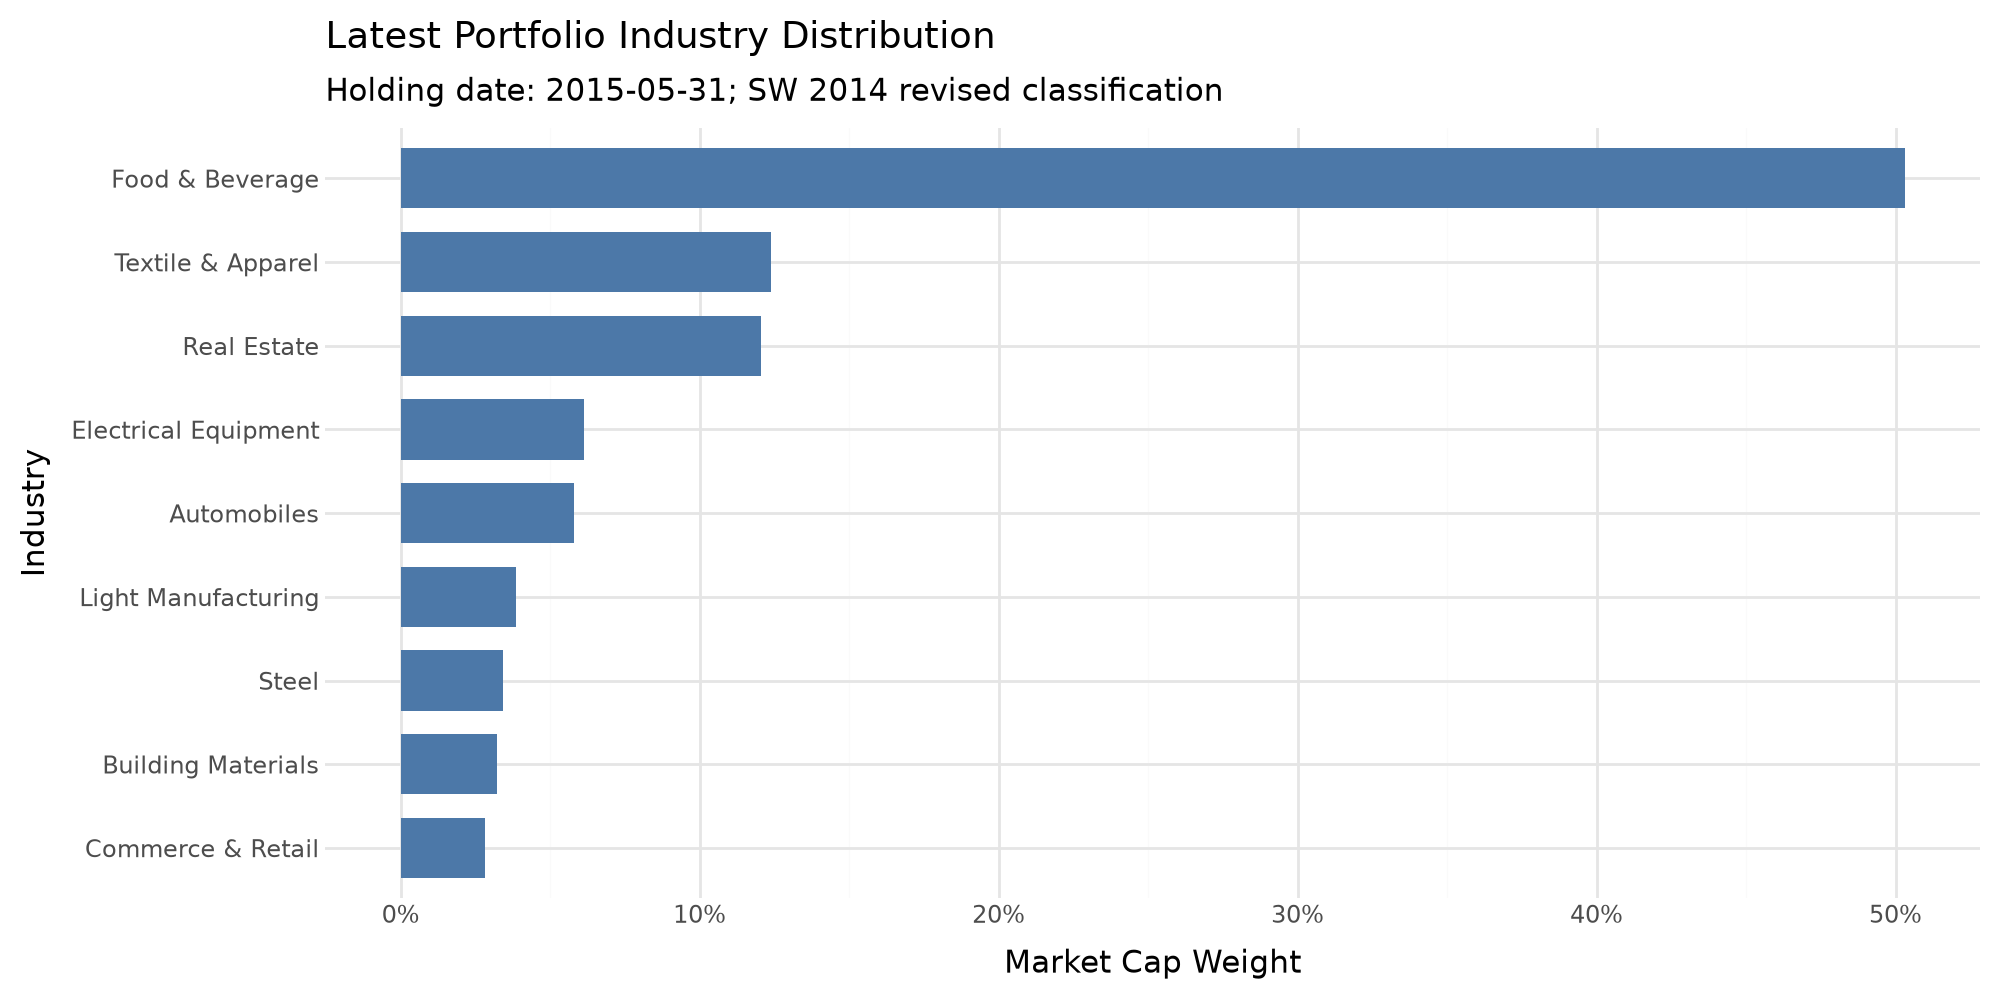

In [44]:
industry_distribution_plot = (
    p9.ggplot(industry_distribution, p9.aes(x='industry_label', y='weight'))
    + p9.geom_col(fill='#4c78a8', width=0.72)
    + p9.coord_flip()
    + p9.scale_y_continuous(labels=lambda values: [f'{value:.0%}' for value in values])
    + p9.labs(
        title='Latest Portfolio Industry Distribution',
        subtitle=f'Holding date: {latest_signal_date:%Y-%m-%d}; SW 2014 revised classification',
        x='Industry',
        y='Market Cap Weight'
    )
    + p9.theme_minimal()
    + p9.theme(figure_size=(10, 5))
)
industry_distribution_plot

In [45]:
market_cap_distribution = (
    latest_portfolio_profile
    .groupby('market_cap_group', observed=False, as_index=False)
    .agg(
        stock_count=('stkcd', 'nunique'),
        market_value=('market_value', 'sum')
    )
    .query("market_cap_group != 'Unknown'")
    .assign(weight=lambda x: x['market_value'] / x['market_value'].sum())
)

market_cap_distribution['market_cap_group'] = pd.Categorical(
    market_cap_distribution['market_cap_group'],
    categories=['Mega Cap', 'Large Cap', 'Mid Cap', 'Small-Mid Cap', 'Small Cap'],
    ordered=True
)
market_cap_distribution

,market_cap_group,stock_count,market_value,weight
0,Mega Cap,1,1.018458e+12,0.503101
1,Large Cap,1,1.828931e+11,0.090346
2,Mid Cap,3,3.447349e+11,0.170293
3,Small-Mid Cap,6,4.211862e+11,0.208059
4,Small Cap,1,5.708825e+10,0.028201


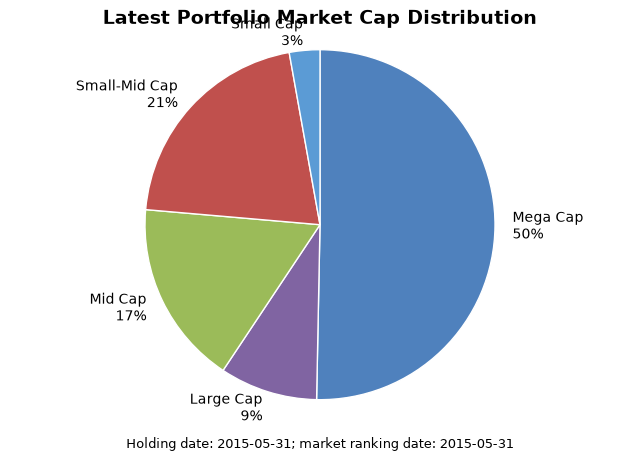

In [46]:
import matplotlib.pyplot as plt

market_cap_pie_data = (
    market_cap_distribution
    .assign(
        market_cap_group=lambda x: pd.Categorical(
            x['market_cap_group'],
            categories=['Mega Cap', 'Large Cap', 'Mid Cap', 'Small-Mid Cap', 'Small Cap'],
            ordered=True
        )
    )
    .sort_values('market_cap_group')
)

market_cap_distribution_plot, ax = plt.subplots(figsize=(8, 5))
colors = ['#4f81bd', '#8064a2', '#9bbb59', '#c0504d', '#5b9bd5']

ax.pie(
    market_cap_pie_data['weight'],
    labels=[
        f"{group}\n{weight:.0%}"
        for group, weight in zip(
            market_cap_pie_data['market_cap_group'],
            market_cap_pie_data['weight']
        )
    ],
    startangle=90,
    counterclock=False,
    colors=colors[:len(market_cap_pie_data)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
    textprops={'fontsize': 10}
)
ax.set_title(
    'Latest Portfolio Market Cap Distribution',
    fontsize=14,
    fontweight='bold'
)
ax.text(
    0.5,
    -0.08,
    f'Holding date: {latest_signal_date:%Y-%m-%d}; market ranking date: {latest_market_date:%Y-%m-%d}',
    transform=ax.transAxes,
    ha='center',
    fontsize=9
)
ax.axis('equal')
market_cap_distribution_plot


说明：本节使用日收盘价自行计算个股日收益，采用“月末信号、下一交易日调仓、持有至下一月末”的口径。交易费用按每次调仓的权重变化金额乘以千分之1.3扣除。若需要严格模拟停牌、涨跌停不可交易、退市收益或复权价格，应进一步补充相应字段。

### 经验教训
1. 本文发现量化规则的文字表述虽然清晰，但在实际落地时仍然容易因为数据口径、变量命名和时间处理不一致而产生明显偏差。首先，对于“每股流动资产至少是股价的 30%”这一条件，不能简单用“流动资产合计/总市值”替代。虽然从数学形式看，若总市值严格等于总股本乘以股价，则二者等价，但在真实数据库中，总市值、总股本和月收盘价往往来自不同字段，可能存在时点、单位、股本口径或价格口径差异。

2. 财报数据的滞后：PE 和股息收益率只用了年报/年度数据，所以直接滞后 4 个月；其他财务指标可能包含季报、半年报、三季报和年报，所以需要用函数按报告期分别处理。股票市值是市场实时公开信息。  
3. 总市值字段不一定等于总股本 × 月收盘价  
4. 总股本和月收盘价的时点不同
TotalShares 是季度/报告期数据，Mclsprc 是月度收盘价。  
我们把总股本按月 forward-fill 后再和月收盘价匹配，更接近“每股流动资产/股价”。
但 Msmvttl 是数据库已经算好的月度市值，里面的股本时点可能和你 总股本.csv 的 TotalShares 不一致。    
5. 单位或股本口径可能不同

在复现史蒂夫·路佛价值选股法则的过程中，本文发现量化规则的文字表述虽然清晰，但在实际落地时仍然容易因为数据口径、变量命名和时间处理不一致而产生明显偏差。首先，对于“每股流动资产至少是股价的 30%”这一条件，不能简单用“流动资产合计/总市值”替代。虽然从数学形式看，若总市值严格等于总股本乘以股价，则二者等价，但在真实数据库中，总市值、总股本和月收盘价往往来自不同字段，可能存在时点、单位、股本口径或价格口径差异。因此，本文最终采用更贴近原始定义的计算方式，即“流动资产合计/总股本/月收盘价”，以减少数据口径不一致带来的误差。

其次，财务数据的可得时间处理非常重要。上市公司财务指标并不能在报告期末立即被投资者使用，若直接以报告期日期参与当月选股，容易产生前视偏差。本文在处理净利润、流动资产、经营现金流、长期借款、流动比率等财报类指标时，按照财报披露滞后的思想进行处理，使选股时点尽量接近真实投资环境。

最后，变量命名和中间结果管理也会影响策略复现的可靠性。若同一变量既用于保存原始财务数据，又用于保存筛选后的因子结果，容易在后续合并股票池时产生逻辑混乱。本文在修正过程中将原始数据和筛选后结果分开命名，例如使用 `current_assets_raw` 和 `current_assets_to_price`，从而避免因变量覆盖或拼写错误导致某些选股条件未真正生效。总体来看，量化策略复现不仅要照搬规则，更要保证数据定义、时间可得性和代码实现三者一致。

PE 和股息收益率只用了年报/年度数据，所以直接滞后 4 个月；其他财务指标可能包含季报、半年报、三季报和年报，所以需要用函数按报告期分别处理。

## 作品总结与研报差异分析

### 项目定位

本文定位为“复现并扩展 Steve Loughran 价值选股策略在 A 股市场的回测研究”，而不是对原研报的完全逐点复刻。项目核心在于将研报中的价值选股规则转化为可执行的量化流程，并完成数据清洗、财报滞后处理、股票池构建、组合回测、绩效评价和可视化展示。

### 与研报结果的对比

| 指标 | 原研报结果 | 本文复现结果 | 说明 |
|---|---:|---:|---|
| 交易日数量 | 2938 | 2851 | 本文日行情和基准合并后起点为 2003-09-01，少于研报口径 |
| 累计收益率 | 1338.8% | 1158.1% | 方向一致，但总收益偏低 |
| 年化收益率 | 23.9% | 24.2% | 与研报较接近 |
| 年化超额收益 | 19.5% | 12.8% | 可能受超额收益定义、基准和起止日影响 |
| 最大回撤 | 66.82% | 65.62% | 与研报较接近 |
| Beta | 1.07 | 1.06 | 与研报较接近 |
| 胜率 | 56.96% | 56.47% | 与研报较接近 |
| 盈亏比 | 0.87 | 0.89 | 与研报较接近 |
| 平均持股数 | 28 | 24.45 | 持股数量分布仍有差异 |

### 差异来源

1. 数据源和样本覆盖不同：本文使用本地可获得的财务、行情和指数数据，交易日数量与研报存在差异。
2. 财报可得时间处理不同：本文对财务指标做了滞后处理，以降低前视偏差，但无法完全确认与研报内部数据库口径一致。
3. 退市股、停牌和涨跌停处理不完整：本文使用可获得的日收盘价进行回测，未严格模拟全部不可交易状态。
4. 行业分类口径不同：本文可获得的申万行业分类为 2014 修订版，因此只展示回测期末持仓的行业分布，不进行 2003-2015 全历史行业归因。
5. 超额收益定义可能不同：本文同时提供组合净值、基准净值和相对强弱图，但原研报对超额收益的具体计算细节未完全披露。

### 作品亮点

1. 将研报中的七条价值筛选规则落地为可复现的 pandas 数据处理流程。
2. 覆盖估值、分红和财务稳健性三个维度，构建多条件股票池。
3. 实现月度调仓、等权配置、交易成本扣除和上证指数基准比较。
4. 输出收益分析、风险分析、盈亏统计、持股数量和最新持仓暴露分析。
5. 使用 plotnine 和 matplotlib 完成净值、超额收益、持股数、行业分布和市值分布图。
6. 对复现结果和研报结果进行逐项对比，并明确说明误差来源。

### 后续优化方向

1. 补充更完整的历史申万行业分类，以进行全历史行业暴露归因。
2. 补充退市股收益、停牌、涨跌停和复权价格，提升交易模拟真实性。
3. 统一研报口径下的交易日、调仓日和基准收益计算方式。
4. 将数据清洗、因子筛选、组合回测和图表输出拆分为可复用模块。
